# Comparaison XGBoost vs Random Forest
## Prédiction de ventes avec méthode récursive

**Objectif**: Comparer les performances de XGBoost et Random Forest pour la prédiction de séries temporelles de ventes.

**Méthodologie**: 
- Utilisation d'une approche récursive où les prédictions d'un pas de temps servent de features pour le pas suivant
- Split temporel: Train / Validation / Test
- Encodages optimisés pour les variables catégorielles
- Exclusion des variables oil_price pour éviter le data leakage

## Table des matières

1. [Configuration de l'environnement](#1-configuration)
2. [Chargement des données](#2-donnees)
3. [Fonctions de modélisation](#3-fonctions)
4. [Configuration des hyperparamètres](#4-hyperparametres)
5. [Entraînement et prédictions](#5-entrainement)
6. [Évaluation des performances](#6-evaluation)
7. [Visualisations comparatives](#7-visualisations)

## 1. Configuration de l'environnement <a id='1-configuration'></a>

Cette section initialise l'environnement de travail et importe les bibliothèques nécessaires.

In [7]:
# Changement du répertoire de travail pour accéder aux modules du projet
import os 
os.chdir("..")

In [8]:
# Imports standards
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Modèles de machine learning
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# Modules personnalisés du projet
from src.feature_engineering import (
    apply_catboost_encoding, 
    apply_robust_scaler, 
    apply_target_encoding, 
    apply_label_encoding_nn
)
from src.evaluation import evaluate_model

# Analyse des features
import shap

## 2. Chargement des données <a id='2-donnees'></a>

Les données sont stockées au format Parquet pour optimiser les performances de lecture.
- **train_sales_data.parquet**: Données d'entraînement historiques
- **test_sales_data.parquet**: Données de test pour les prédictions futures

In [9]:
# Chargement des datasets
train = pd.read_parquet('data/train_sales_data.parquet')
test = pd.read_parquet('data/test_sales_data.parquet')

# Affichage des dimensions
print(f"Données d'entraînement: {train.shape}")
print(f"Données de test: {test.shape}")

Données d'entraînement: (2901096, 44)
Données de test: (99792, 44)


In [10]:
def compute_catboost_encoding_at_date(historical_df, current_df, cols, target, alpha=None):
    """
    Calcule l'encodage CatBoost pour current_df en utilisant UNIQUEMENT historical_df.
    
    Parameters
    ----------
    historical_df : pd.DataFrame
        Données historiques (train + prédictions précédentes)
    current_df : pd.DataFrame  
        Données du jour actuel à encoder
    cols : list
        Colonnes catégorielles à encoder
    target : str
        Nom de la colonne cible
    alpha : float, optional
        Paramètre de smoothing
        
    Returns
    -------
    pd.DataFrame
        current_df avec colonnes catboost_enc_* ajoutées
    """
    
    current_encoded = current_df.copy()
    global_mean = historical_df[target].mean()
    
    for col in cols:
        # Calcul dynamique de alpha
        if alpha is None:
            n_categories = historical_df[col].nunique()
            current_alpha = np.log1p(n_categories) * 5
        else:
            current_alpha = alpha
        
        # Calculer les statistiques sur l'historique
        group_stats = historical_df.groupby(col)[target].agg(['sum', 'count'])
        
        # Formule CatBoost
        encoding_map = (
            (group_stats['sum'] + current_alpha * global_mean) / 
            (group_stats['count'] + current_alpha)
        ).to_dict()
        
        # Appliquer l'encodage
        col_name = f'catboost_enc_{col}'
        current_encoded[col_name] = current_encoded[col].map(encoding_map).fillna(global_mean)
    
    return current_encoded

## 3. Fonctions de modélisation <a id='3-fonctions'></a>

Cette section définit les fonctions principales pour l'entraînement et l'évaluation des modèles.

### 3.1 Fonction XGBoost avec prédiction récursive

**Principe de la prédiction récursive**:
1. On prédit le premier jour de test avec les vraies valeurs d'entraînement
2. Cette prédiction devient une feature pour prédire le jour suivant
3. On répète le processus pour chaque jour de la période de test

**Optimisations clés**:
- Les encodages sont calculés une seule fois sur le train complet
- Les prédictions sont clippées à 0 (pas de ventes négatives)
- Exclusion des variables oil_price pour éviter le data leakage

In [11]:
# ============================================================================
# NOTEBOOK COMPLET: COMPARAISON XGBoost vs Random Forest
# Prédiction récursive avec Train/Validation/Test Split
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')
def process_single_day_xgb(current_date, combined_data, catboost_cols, target, features, 
                           original_cols_that_were_scaled, scaler, model):
    """
    Traite un seul jour de prédiction pour XGBoost (fonction optimisée).
    
    Returns
    -------
    tuple
        (day_results_df, y_pred_day, day_indices)
    """
    
    # ====================================================================
    # ÉTAPE 1: RECALCULER ENCODAGES CATBOOST
    # ====================================================================
    
    historical_mask = combined_data['date'] < current_date
    historical_data = combined_data[historical_mask]
    global_mean = historical_data[target].mean()
    
    catboost_encodings = {}
    for cat_col in catboost_cols:
        n_categories = historical_data[cat_col].nunique()
        alpha = np.log1p(n_categories) * 5
        
        group_stats = historical_data.groupby(cat_col)[target].agg(['sum', 'count'])
        catboost_encodings[cat_col] = (
            (group_stats['sum'] + alpha * global_mean) / 
            (group_stats['count'] + alpha)
        ).to_dict()
    
    # Données du jour
    day_mask = (combined_data['date'] == current_date)
    day_data = combined_data[day_mask].copy()
    
    if len(day_data) == 0:
        return None, None, None
    
    # Appliquer encodages
    for cat_col in catboost_cols:
        col_name = f'catboost_enc_{cat_col}'
        encoded_series = day_data[cat_col].map(catboost_encodings[cat_col])
        encoded_values = encoded_series.values
        encoded_values = np.where(np.isnan(encoded_values), global_mean, encoded_values)
        day_data[col_name] = encoded_values
    
    # ====================================================================
    # ÉTAPE 2: METTRE À JOUR LES LAGS (VECTORISÉ)
    # ====================================================================
    
    for lag_days in [1, 2, 3, 7, 14, 28, 56]:
        lag_col = f'sales_lag_{lag_days}'
        if lag_col not in day_data.columns:
            continue
        
        lag_date = current_date - pd.Timedelta(days=lag_days)
        
        # Vectorisé: récupérer toutes les valeurs en une fois
        lag_values = combined_data[combined_data['date'] == lag_date][
            ['store_nbr', 'family', target]
        ].rename(columns={target: f'{lag_col}_temp'})
        
        day_data = day_data.merge(lag_values, on=['store_nbr', 'family'], how='left')
        
        mask = day_data[f'{lag_col}_temp'].notna()
        if mask.sum() > 0:
            day_data.loc[mask, lag_col] = day_data.loc[mask, f'{lag_col}_temp']
        day_data.drop(columns=[f'{lag_col}_temp'], inplace=True)
    
    # ====================================================================
    # ÉTAPE 3: METTRE À JOUR LES ROLLING MEANS (VECTORISÉ)
    # ====================================================================
    
    for window in [7, 14, 28]:
        rolling_col = f'rolling_mean_{window}'
        if rolling_col not in day_data.columns:
            continue
        
        start_date = current_date - pd.Timedelta(days=window)
        
        # Vectorisé: calculer toutes les rolling means en une fois
        rolling_window_data = combined_data[
            (combined_data['date'] >= start_date) & 
            (combined_data['date'] < current_date)
        ]
        
        rolling_means = rolling_window_data.groupby(['store_nbr', 'family'])[target].mean().reset_index()
        rolling_means = rolling_means.rename(columns={target: f'{rolling_col}_temp'})
        
        day_data = day_data.merge(rolling_means, on=['store_nbr', 'family'], how='left')
        
        mask = day_data[f'{rolling_col}_temp'].notna()
        if mask.sum() > 0:
            day_data.loc[mask, rolling_col] = day_data.loc[mask, f'{rolling_col}_temp']
        day_data.drop(columns=[f'{rolling_col}_temp'], inplace=True)
    
    # ====================================================================
    # ÉTAPE 4: APPLIQUER LE SCALER
    # ====================================================================
    
    cols_to_scale = [c for c in original_cols_that_were_scaled if c in day_data.columns]
    
    if len(cols_to_scale) > 0:
        scaled_values = scaler.transform(day_data[cols_to_scale])
        for i, col_name in enumerate(cols_to_scale):
            scaled_col_name = f'scaled_{col_name}'
            if scaled_col_name in features:
                day_data[scaled_col_name] = scaled_values[:, i]
    
    # ====================================================================
    # ÉTAPE 5: PRÉDICTION
    # ====================================================================
    
    X_day = day_data[features]
    y_pred_day = model.predict(X_day)
    y_pred_day = np.maximum(y_pred_day, 0)
    
    # Résultat
    day_indices = combined_data[day_mask].index
    day_results = pd.DataFrame({
        'date': combined_data.loc[day_indices, 'date'].values,
        'store_nbr': combined_data.loc[day_indices, 'store_nbr'].values,
        'family': combined_data.loc[day_indices, 'family'].values,
        'y_pred': y_pred_day
    })
    
    return day_results, y_pred_day, day_indices


def train_and_evaluate_split_recursive_optimized(train_df, test_df, split_config, use_gpu=False, hyperparams=None):
    """
    Prédiction récursive XGBoost OPTIMISÉE et SANS LEAKAGE.
    
    IMPORTANT: 
    - Variables oil_price exclues pour éviter le data leakage
    - Encodages CatBoost recalculés dynamiquement à chaque jour
    - Lags et rolling means vectorisés pour performance
    
    Parameters
    ----------
    train_df : pd.DataFrame
        Dataframe d'entrainement complet
    test_df : pd.DataFrame
        Dataframe de test final
    split_config : dict
        Configuration du split avec clés:
        - 'name': nom du split
        - 'use_real_test': True pour utiliser test_df, False pour split sur train_df
        - 'train_end': date de fin du train (si use_real_test=False)
        - 'test_start': date de début du test (si use_real_test=False)
        - 'test_end': date de fin du test (si use_real_test=False)
    use_gpu : bool
        Utiliser le GPU pour XGBoost
    hyperparams : dict, optional
        Dictionnaire des hyperparamètres XGBoost
    
    Returns
    -------
    dict
        Dictionnaire contenant les resultats, metriques et predictions
    """
    
    warnings.filterwarnings('ignore')
    
    # ========================================================================
    # CONFIGURATION
    # ========================================================================
    
    # Hyperparamètres par défaut
    if hyperparams is None:
        hyperparams = {
            'max_depth': 8,
            'learning_rate': 0.05,
            'n_estimators': 500,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'min_child_weight': 5
        }
    
    # Creation des ensembles train et test
    if split_config['use_real_test']:
        train_split = train_df.copy()
        test_split = test_df.copy()
    else:
        train_split = train_df[train_df['date'] <= split_config['train_end']].copy()
        test_split = train_df[
            (train_df['date'] >= split_config['test_start']) & 
            (train_df['date'] <= split_config['test_end'])
        ].copy()
    
    if len(test_split) == 0:
        return None
    
    print(f"Train: {train_split['date'].min()} -> {train_split['date'].max()}")
    print(f"Test:  {test_split['date'].min()} -> {test_split['date'].max()}")
    print(f"GPU:   {'Activé' if use_gpu else 'Désactivé'}")
    
    # ========================================================================
    # PHASE 1: PREPARATION INITIALE (encodage sur train uniquement)
    # ========================================================================
    
    print("\n[1/4] Feature engineering sur train...")
    
    target = 'sales'
    catboost_cols = ['store_nbr', 'family', 'city', 'cluster']
    
    train_processed = apply_catboost_encoding(
        train_split,
        cols=catboost_cols,
        target=target,
        nb_previous_days_to_ignore=56,
        fill_first_na=True
    )
    
    train_scaled, scaler = apply_robust_scaler(
        train_processed,
        exclude_cols=['id', 'date', 'store_nbr', 'family', 'city', 'state', 
                      'store_type', 'cluster', 'sales', 'log_sales',
                      'is_holiday_local', 'is_holiday_regional', 
                      'is_holiday_national', 'is_store_closed', 
                      'is_weekend', 'is_payday', 'is_earthquake_impact',
                      'is_family_unactive', 'holiday_type'],
        drop_original=True
    )
    
    # Definition des features
    exclude_from_features = [
        'id', 'date', 'sales', 'log_sales',
        'store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'holiday_type',
        'oil_price', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30'
    ]

    features = []
    for col in train_scaled.columns:
        if col in exclude_from_features:
            continue
        if train_scaled[col].dtype in ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', 'bool']:
            features.append(col)
    
    # Identifier les colonnes scalées
    scaled_cols_in_train = [c for c in train_scaled.columns if c.startswith('scaled_')]
    original_cols_that_were_scaled = [c.replace('scaled_', '') for c in scaled_cols_in_train]
    
    X_train = train_scaled[features]
    y_train = train_scaled[target]
    
    print(f"Nombre de features: {len(features)}")
    print(f"  Variables oil_price EXCLUES (éviter data leakage)")
    
    # ========================================================================
    # PHASE 2: ENTRAINEMENT XGBOOST
    # ========================================================================
    
    print(f"\n[2/4] Entrainement XGBoost {'sur GPU' if use_gpu else 'sur CPU'}...")
    print(f"Hyperparams: max_depth={hyperparams['max_depth']}, lr={hyperparams['learning_rate']}, n_est={hyperparams['n_estimators']}")
    
    if use_gpu:
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            max_depth=hyperparams['max_depth'],
            learning_rate=hyperparams['learning_rate'],
            n_estimators=hyperparams['n_estimators'],
            subsample=hyperparams['subsample'],
            colsample_bytree=hyperparams['colsample_bytree'],
            min_child_weight=hyperparams['min_child_weight'],
            random_state=42,
            tree_method='hist',
            device='cuda',
            n_jobs=1
        )
    else:
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            max_depth=hyperparams['max_depth'],
            learning_rate=hyperparams['learning_rate'],
            n_estimators=hyperparams['n_estimators'],
            subsample=hyperparams['subsample'],
            colsample_bytree=hyperparams['colsample_bytree'],
            min_child_weight=hyperparams['min_child_weight'],
            random_state=42,
            tree_method='hist',
            device='cpu',
            n_jobs=-1
        )
    
    model.fit(X_train, y_train, verbose=False)
    print("Entraînement terminé")
    
    # ========================================================================
    # PHASE 3: PREPARATION POUR PREDICTION RECURSIVE
    # ========================================================================
    
    print("\n[3/4] Préparation pour prédiction récursive...")
    
    # Combiner train et test SANS encodage CatBoost préalable
    combined_data = pd.concat([train_split, test_split], ignore_index=True).copy()
    combined_data = combined_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
    
    # Convertir colonnes catégorielles en object
    for cat_col in catboost_cols:
        if combined_data[cat_col].dtype.name == 'category':
            combined_data[cat_col] = combined_data[cat_col].astype('object')
    
    print("Données préparées (tri effectué)")
    
    # ========================================================================
    # PHASE 4: PREDICTION RECURSIVE OPTIMISÉE
    # ========================================================================
    
    test_dates = sorted(test_split['date'].unique())
    print(f"\n[4/4] Prédiction récursive OPTIMISÉE sur {len(test_dates)} jours...")
    
    predictions_list = []
    n_clipped = 0
    
    for day_idx, current_date in enumerate(test_dates):
        
        result = process_single_day_xgb(
            current_date, combined_data, catboost_cols, target, features,
            original_cols_that_were_scaled, scaler, model
        )
        
        if result[0] is None:
            continue
        
        day_results, y_pred_day, day_indices = result
        
        # Mise à jour pour récursivité
        combined_data.loc[day_indices, target] = y_pred_day
        
        n_clipped += (y_pred_day < 0).sum()
        predictions_list.append(day_results)
        
        if (day_idx + 1) % 7 == 0 or day_idx == 0:
            print(f"  {day_idx + 1}/{len(test_dates)} jours traités")
    
    if n_clipped > 0:
        print(f"\n  {n_clipped} prédictions négatives clippées à 0")
    else:
        print(f"\n  Aucune prédiction négative")
    
    # ========================================================================
    # CONSOLIDATION ET ÉVALUATION
    # ========================================================================
    
    all_predictions = pd.concat(predictions_list, ignore_index=True)
    
    test_split_sorted = test_split.sort_values(['date', 'store_nbr', 'family']).reset_index(drop=True)
    all_predictions = all_predictions.merge(
        test_split_sorted[['date', 'store_nbr', 'family', 'sales', 'is_store_closed', 'is_family_unactive']],
        on=['date', 'store_nbr', 'family'],
        how='left'
    )
    all_predictions = all_predictions.rename(columns={'sales': 'y_true'})
    
    print("\n[Evaluation] Calcul des métriques...")
    metrics = evaluate_model(
        y_true=all_predictions['y_true'].values,
        y_pred=all_predictions['y_pred'].values,
        is_store_closed=all_predictions['is_store_closed'].values,
        is_family_unactive=all_predictions['is_family_unactive'].values
    )
    
    results = {
        'split_name': split_config['name'] + ' (Recursive)',
        'train_size': len(train_split),
        'test_size': len(test_split),
        'train_start': train_split['date'].min(),
        'train_end': train_split['date'].max(),
        'test_start': test_split['date'].min(),
        'test_end': test_split['date'].max(),
        'metrics': metrics,
        'model': model,
        'features': features,
        'scaler': scaler,
        'predictions': all_predictions,
        'use_gpu': use_gpu,
        'n_clipped': n_clipped,
        'hyperparams': hyperparams
    }
    
    return results

### 3.2 Fonction Random Forest avec prédiction récursive

Implémentation similaire à XGBoost mais utilisant Random Forest comme modèle de base.
Les mêmes principes d'optimisation et de prédiction récursive s'appliquent.

In [12]:
def train_and_evaluate_split_rf_recursive(train_df, test_df, split_config, hyperparams=None):
    """
    Prédiction récursive Random Forest SANS LEAKAGE.
    
    IMPORTANT:
    - Variables oil_price exclues pour éviter le data leakage
    - Encodages CatBoost recalculés dynamiquement à chaque jour
    - Lags et rolling means mis à jour avec les prédictions
    
    Parameters
    ----------
    train_df : pd.DataFrame
        Dataframe d'entrainement complet
    test_df : pd.DataFrame
        Dataframe de test final
    split_config : dict
        Configuration du split
    hyperparams : dict, optional
        Hyperparametres Random Forest personnalises
    
    Returns
    -------
    dict
        Dictionnaire contenant les resultats, metriques et predictions
    """
    
    warnings.filterwarnings('ignore')
    
    # ========================================================================
    # CONFIGURATION
    # ========================================================================
    
    # Creation des ensembles train et test pour ce split
    if split_config['use_real_test']:
        train_split = train_df.copy()
        test_split = test_df.copy()
    else:
        train_split = train_df[train_df['date'] <= split_config['train_end']].copy()
        test_split = train_df[
            (train_df['date'] >= split_config['test_start']) & 
            (train_df['date'] <= split_config['test_end'])
        ].copy()
    
    if len(test_split) == 0:
        return None
    
    print(f"Train: {train_split['date'].min()} -> {train_split['date'].max()}")
    print(f"Test:  {test_split['date'].min()} -> {test_split['date'].max()}")
    
    # ========================================================================
    # PHASE 1: PREPARATION INITIALE (encodage sur train uniquement)
    # ========================================================================
    
    print("\n[1/4] Feature engineering sur train...")
    
    target = 'sales'
    catboost_cols = ['store_nbr', 'family', 'city', 'cluster']
    
    # Encodage initial sur train
    train_processed = apply_catboost_encoding(
        train_split,
        cols=catboost_cols,
        target=target,
        nb_previous_days_to_ignore=56,
        fill_first_na=True
    )
    
    train_scaled, scaler = apply_robust_scaler(
        train_processed,
        exclude_cols=['id', 'date', 'store_nbr', 'family', 'city', 'state', 
                      'store_type', 'cluster', 'sales', 'log_sales',
                      'is_holiday_local', 'is_holiday_regional', 
                      'is_holiday_national', 'is_store_closed', 
                      'is_weekend', 'is_payday', 'is_earthquake_impact',
                      'is_family_unactive', 'holiday_type'],
        drop_original=True
    )
    
    # Definition des features
    exclude_from_features = [
        'id', 'date', 'sales', 'log_sales',
        'store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'holiday_type',
        'oil_price', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30'
    ]

    features = []
    for col in train_scaled.columns:
        if col in exclude_from_features:
            continue
        if train_scaled[col].dtype in ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', 'bool']:
            features.append(col)
    
    # Identifier les colonnes qui ont été scalées
    scaled_cols_in_train = [c for c in train_scaled.columns if c.startswith('scaled_')]
    original_cols_that_were_scaled = [c.replace('scaled_', '') for c in scaled_cols_in_train]
    
    X_train = train_scaled[features]
    y_train = train_scaled[target]
    
    print(f"Nombre de features: {len(features)}")
    print(f"  Variables oil_price EXCLUES (éviter data leakage)")
    
    # ========================================================================
    # PHASE 2: ENTRAINEMENT RANDOM FOREST
    # ========================================================================
    
    print(f"\n[2/4] Entrainement Random Forest...")
    
    if hyperparams is None:
        hyperparams = {
            'n_estimators': 200,
            'max_depth': 20,
            'min_samples_split': 10,
            'min_samples_leaf': 5,
            'max_features': 'sqrt',
            'bootstrap': True,
            'n_jobs': -1,
            'random_state': 42
        }
    
    print(f"Hyperparams: n_est={hyperparams['n_estimators']}, max_depth={hyperparams['max_depth']}")
    
    model = RandomForestRegressor(**hyperparams)
    model.fit(X_train, y_train)
    print("Entraînement terminé")
    
    # ========================================================================
    # PHASE 3: PREPARATION POUR PREDICTION RECURSIVE
    # ========================================================================
    
    print("\n[3/4] Préparation pour prédiction récursive...")
    
    # Combiner train et test SANS encodage CatBoost préalable
    combined_data = pd.concat([train_split, test_split], ignore_index=True).copy()
    combined_data = combined_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
    
    # IMPORTANT: Convertir les colonnes catégorielles en type object
    for cat_col in catboost_cols:
        if combined_data[cat_col].dtype.name == 'category':
            combined_data[cat_col] = combined_data[cat_col].astype('object')
    
    print("Données préparées (tri effectué)")
    
    # ========================================================================
    # PHASE 4: PREDICTION RECURSIVE AVEC ENCODAGE DYNAMIQUE
    # ========================================================================
    
    test_dates = sorted(test_split['date'].unique())
    print(f"\n[4/4] Prédiction récursive sur {len(test_dates)} jours...")
    
    predictions_list = []
    n_clipped = 0
    
    for day_idx, current_date in enumerate(test_dates):
        
        # ====================================================================
        # ÉTAPE 1: RECALCULER ENCODAGES CATBOOST dynamiquement
        # ====================================================================
        
        # Historique strict (jusqu'à la veille, inclut prédictions précédentes)
        historical_mask = combined_data['date'] < current_date
        historical_data = combined_data[historical_mask]
        
        # Moyenne globale sur historique à jour
        global_mean = historical_data[target].mean()
        
        # Calculer les encodages CatBoost sur l'historique
        catboost_encodings = {}
        for cat_col in catboost_cols:
            n_categories = historical_data[cat_col].nunique()
            alpha = np.log1p(n_categories) * 5
            
            group_stats = historical_data.groupby(cat_col)[target].agg(['sum', 'count'])
            catboost_encodings[cat_col] = (
                (group_stats['sum'] + alpha * global_mean) / 
                (group_stats['count'] + alpha)
            ).to_dict()
        
        # Données du jour
        day_mask = (combined_data['date'] == current_date)
        day_data = combined_data[day_mask].copy()
        
        if len(day_data) == 0:
            continue
        
        # Appliquer les encodages CatBoost mis à jour
        for cat_col in catboost_cols:
            col_name = f'catboost_enc_{cat_col}'
            # CORRECTION: Créer une Series standard avant fillna
            encoded_series = day_data[cat_col].map(catboost_encodings[cat_col])
            # Convertir en array numpy pour éviter le problème de categorical
            encoded_values = encoded_series.values
            # Remplir les NaN
            encoded_values = np.where(np.isnan(encoded_values), global_mean, encoded_values)
            day_data[col_name] = encoded_values
        
        # ====================================================================
        # ÉTAPE 2: METTRE À JOUR LES LAGS
        # ====================================================================
        
        for lag_days in [1, 2, 3, 7, 14, 28, 56]:
            lag_col = f'sales_lag_{lag_days}'
            if lag_col not in day_data.columns:
                continue
            
            lag_date = current_date - pd.Timedelta(days=lag_days)
            
            # Pour chaque ligne du jour
            for local_idx in range(len(day_data)):
                global_idx = day_data.index[local_idx]
                store = combined_data.loc[global_idx, 'store_nbr']
                family = combined_data.loc[global_idx, 'family']
                
                # Récupérer la valeur du lag depuis l'historique
                lag_mask = (
                    (combined_data['store_nbr'] == store) &
                    (combined_data['family'] == family) &
                    (combined_data['date'] == lag_date)
                )
                
                if lag_mask.sum() > 0:
                    lag_value = combined_data.loc[lag_mask, target].iloc[0]
                    day_data.iloc[local_idx, day_data.columns.get_loc(lag_col)] = lag_value
        
        # ====================================================================
        # ÉTAPE 3: METTRE À JOUR LES ROLLING MEANS
        # ====================================================================
        
        for window in [7, 14, 28]:
            rolling_col = f'rolling_mean_{window}'
            if rolling_col not in day_data.columns:
                continue
            
            for local_idx in range(len(day_data)):
                global_idx = day_data.index[local_idx]
                store = combined_data.loc[global_idx, 'store_nbr']
                family = combined_data.loc[global_idx, 'family']
                
                # Calculer la rolling mean sur la fenêtre
                rolling_mask = (
                    (combined_data['store_nbr'] == store) &
                    (combined_data['family'] == family) &
                    (combined_data['date'] >= current_date - pd.Timedelta(days=window)) &
                    (combined_data['date'] < current_date)
                )
                
                if rolling_mask.sum() > 0:
                    rolling_value = combined_data.loc[rolling_mask, target].mean()
                    day_data.iloc[local_idx, day_data.columns.get_loc(rolling_col)] = rolling_value
        
        # ====================================================================
        # ÉTAPE 4: APPLIQUER LE SCALER sur les colonnes nécessaires
        # ====================================================================
        
        cols_to_scale = [c for c in original_cols_that_were_scaled if c in day_data.columns]
        
        if len(cols_to_scale) > 0:
            scaled_values = scaler.transform(day_data[cols_to_scale])
            for i, col_name in enumerate(cols_to_scale):
                scaled_col_name = f'scaled_{col_name}'
                if scaled_col_name in features:
                    day_data[scaled_col_name] = scaled_values[:, i]
        
        # ====================================================================
        # ÉTAPE 5: PRÉDICTION
        # ====================================================================
        
        X_day = day_data[features]
        y_pred_day = model.predict(X_day)
        
        # Clipping à 0
        n_negative = (y_pred_day < 0).sum()
        n_clipped += n_negative
        y_pred_day = np.maximum(y_pred_day, 0)
        
        # ====================================================================
        # ÉTAPE 6: MISE À JOUR DES SALES dans combined_data
        # ====================================================================
        
        day_indices = combined_data[day_mask].index
        combined_data.loc[day_indices, target] = y_pred_day
        
        # Stocker les prédictions
        day_results = pd.DataFrame({
            'date': combined_data.loc[day_indices, 'date'].values,
            'store_nbr': combined_data.loc[day_indices, 'store_nbr'].values,
            'family': combined_data.loc[day_indices, 'family'].values,
            'y_pred': y_pred_day
        })
        predictions_list.append(day_results)
        
        if (day_idx + 1) % 7 == 0 or day_idx == 0:
            print(f"  {day_idx + 1}/{len(test_dates)} jours traités")
    
    # Afficher clipping
    if n_clipped > 0:
        print(f"\n  {n_clipped} prédictions négatives clippées à 0")
    else:
        print(f"\n  Aucune prédiction négative")
    
    # ========================================================================
    # CONSOLIDATION ET ÉVALUATION
    # ========================================================================
    
    # Combiner prédictions
    all_predictions = pd.concat(predictions_list, ignore_index=True)
    
    # Récupérer vraies valeurs
    test_split_sorted = test_split.sort_values(['date', 'store_nbr', 'family']).reset_index(drop=True)
    all_predictions = all_predictions.merge(
        test_split_sorted[['date', 'store_nbr', 'family', 'sales', 'is_store_closed', 'is_family_unactive']],
        on=['date', 'store_nbr', 'family'],
        how='left'
    )
    all_predictions = all_predictions.rename(columns={'sales': 'y_true'})
    
    # Evaluation
    print("\n[Evaluation] Calcul des métriques...")
    metrics = evaluate_model(
        y_true=all_predictions['y_true'].values,
        y_pred=all_predictions['y_pred'].values,
        is_store_closed=all_predictions['is_store_closed'].values,
        is_family_unactive=all_predictions['is_family_unactive'].values
    )
    
    results = {
        'split_name': split_config['name'] + ' (RF Recursive)',
        'train_size': len(train_split),
        'test_size': len(test_split),
        'train_start': train_split['date'].min(),
        'train_end': train_split['date'].max(),
        'test_start': test_split['date'].min(),
        'test_end': test_split['date'].max(),
        'metrics': metrics,
        'model': model,
        'features': features,
        'scaler': scaler,
        'predictions': all_predictions,
        'n_clipped': n_clipped,
        'hyperparams': hyperparams
    }
    
    return results

In [13]:
from joblib import Parallel, delayed
import multiprocessing

def process_single_day(current_date, combined_data, catboost_cols, target, features, 
                       original_cols_that_were_scaled, scaler, model):
    """
    Traite un seul jour de prédiction (fonction pour parallélisation).
    
    Returns
    -------
    tuple
        (day_results_df, y_pred_day, day_indices)
    """
    
    # ====================================================================
    # ÉTAPE 1: RECALCULER ENCODAGES CATBOOST
    # ====================================================================
    
    historical_mask = combined_data['date'] < current_date
    historical_data = combined_data[historical_mask]
    global_mean = historical_data[target].mean()
    
    catboost_encodings = {}
    for cat_col in catboost_cols:
        n_categories = historical_data[cat_col].nunique()
        alpha = np.log1p(n_categories) * 5
        
        group_stats = historical_data.groupby(cat_col)[target].agg(['sum', 'count'])
        catboost_encodings[cat_col] = (
            (group_stats['sum'] + alpha * global_mean) / 
            (group_stats['count'] + alpha)
        ).to_dict()
    
    # Données du jour
    day_mask = (combined_data['date'] == current_date)
    day_data = combined_data[day_mask].copy()
    
    if len(day_data) == 0:
        return None, None, None
    
    # Appliquer encodages
    for cat_col in catboost_cols:
        col_name = f'catboost_enc_{cat_col}'
        encoded_series = day_data[cat_col].map(catboost_encodings[cat_col])
        encoded_values = encoded_series.values
        encoded_values = np.where(np.isnan(encoded_values), global_mean, encoded_values)
        day_data[col_name] = encoded_values
    
    # ====================================================================
    # ÉTAPE 2: METTRE À JOUR LES LAGS (VECTORISÉ)
    # ====================================================================
    
    for lag_days in [1, 2, 3, 7, 14, 28, 56]:
        lag_col = f'sales_lag_{lag_days}'
        if lag_col not in day_data.columns:
            continue
        
        lag_date = current_date - pd.Timedelta(days=lag_days)
        
        # Vectorisé: récupérer toutes les valeurs en une fois
        lag_values = combined_data[combined_data['date'] == lag_date][
            ['store_nbr', 'family', target]
        ].rename(columns={target: f'{lag_col}_temp'})
        
        day_data = day_data.merge(lag_values, on=['store_nbr', 'family'], how='left')
        
        mask = day_data[f'{lag_col}_temp'].notna()
        if mask.sum() > 0:
            day_data.loc[mask, lag_col] = day_data.loc[mask, f'{lag_col}_temp']
        day_data.drop(columns=[f'{lag_col}_temp'], inplace=True)
    
    # ====================================================================
    # ÉTAPE 3: METTRE À JOUR LES ROLLING MEANS (VECTORISÉ)
    # ====================================================================
    
    for window in [7, 14, 28]:
        rolling_col = f'rolling_mean_{window}'
        if rolling_col not in day_data.columns:
            continue
        
        start_date = current_date - pd.Timedelta(days=window)
        
        # Vectorisé: calculer toutes les rolling means en une fois
        rolling_window_data = combined_data[
            (combined_data['date'] >= start_date) & 
            (combined_data['date'] < current_date)
        ]
        
        rolling_means = rolling_window_data.groupby(['store_nbr', 'family'])[target].mean().reset_index()
        rolling_means = rolling_means.rename(columns={target: f'{rolling_col}_temp'})
        
        day_data = day_data.merge(rolling_means, on=['store_nbr', 'family'], how='left')
        
        mask = day_data[f'{rolling_col}_temp'].notna()
        if mask.sum() > 0:
            day_data.loc[mask, rolling_col] = day_data.loc[mask, f'{rolling_col}_temp']
        day_data.drop(columns=[f'{rolling_col}_temp'], inplace=True)
    
    # ====================================================================
    # ÉTAPE 4: APPLIQUER LE SCALER
    # ====================================================================
    
    cols_to_scale = [c for c in original_cols_that_were_scaled if c in day_data.columns]
    
    if len(cols_to_scale) > 0:
        scaled_values = scaler.transform(day_data[cols_to_scale])
        for i, col_name in enumerate(cols_to_scale):
            scaled_col_name = f'scaled_{col_name}'
            if scaled_col_name in features:
                day_data[scaled_col_name] = scaled_values[:, i]
    
    # ====================================================================
    # ÉTAPE 5: PRÉDICTION
    # ====================================================================
    
    X_day = day_data[features]
    y_pred_day = model.predict(X_day)
    y_pred_day = np.maximum(y_pred_day, 0)
    
    # Résultat
    day_indices = combined_data[day_mask].index
    day_results = pd.DataFrame({
        'date': combined_data.loc[day_indices, 'date'].values,
        'store_nbr': combined_data.loc[day_indices, 'store_nbr'].values,
        'family': combined_data.loc[day_indices, 'family'].values,
        'y_pred': y_pred_day
    })
    
    return day_results, y_pred_day, day_indices


def train_and_evaluate_split_rf_recursive(train_df, test_df, split_config, hyperparams=None, n_jobs=-1):
    """
    Prédiction récursive Random Forest PARALLÉLISÉE et OPTIMISÉE.
    
    IMPORTANT:
    - Variables oil_price exclues pour éviter le data leakage
    - Encodages CatBoost recalculés dynamiquement à chaque jour
    - Parallélisation des jours pour accélérer le calcul
    
    Parameters
    ----------
    train_df : pd.DataFrame
        Dataframe d'entrainement complet
    test_df : pd.DataFrame
        Dataframe de test final
    split_config : dict
        Configuration du split
    hyperparams : dict, optional
        Hyperparametres Random Forest personnalises
    n_jobs : int, default=-1
        Nombre de CPU à utiliser (-1 = tous)
    
    Returns
    -------
    dict
        Dictionnaire contenant les resultats, metriques et predictions
    """
    
    warnings.filterwarnings('ignore')
    
    # ========================================================================
    # CONFIGURATION
    # ========================================================================
    
    if split_config['use_real_test']:
        train_split = train_df.copy()
        test_split = test_df.copy()
    else:
        train_split = train_df[train_df['date'] <= split_config['train_end']].copy()
        test_split = train_df[
            (train_df['date'] >= split_config['test_start']) & 
            (train_df['date'] <= split_config['test_end'])
        ].copy()
    
    if len(test_split) == 0:
        return None
    
    print(f"Train: {train_split['date'].min()} -> {train_split['date'].max()}")
    print(f"Test:  {test_split['date'].min()} -> {test_split['date'].max()}")
    
    # ========================================================================
    # PHASE 1: PREPARATION INITIALE
    # ========================================================================
    
    print("\n[1/4] Feature engineering sur train...")
    
    target = 'sales'
    catboost_cols = ['store_nbr', 'family', 'city', 'cluster']
    
    train_processed = apply_catboost_encoding(
        train_split,
        cols=catboost_cols,
        target=target,
        nb_previous_days_to_ignore=56,
        fill_first_na=True
    )
    
    train_scaled, scaler = apply_robust_scaler(
        train_processed,
        exclude_cols=['id', 'date', 'store_nbr', 'family', 'city', 'state', 
                      'store_type', 'cluster', 'sales', 'log_sales',
                      'is_holiday_local', 'is_holiday_regional', 
                      'is_holiday_national', 'is_store_closed', 
                      'is_weekend', 'is_payday', 'is_earthquake_impact',
                      'is_family_unactive', 'holiday_type'],
        drop_original=True
    )
    
    exclude_from_features = [
        'id', 'date', 'sales', 'log_sales',
        'store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'holiday_type',
        'oil_price', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30'
    ]

    features = []
    for col in train_scaled.columns:
        if col in exclude_from_features:
            continue
        if train_scaled[col].dtype in ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', 'bool']:
            features.append(col)
    
    scaled_cols_in_train = [c for c in train_scaled.columns if c.startswith('scaled_')]
    original_cols_that_were_scaled = [c.replace('scaled_', '') for c in scaled_cols_in_train]
    
    X_train = train_scaled[features]
    y_train = train_scaled[target]
    
    print(f"Nombre de features: {len(features)}")
    print(f"  Variables oil_price EXCLUES (éviter data leakage)")
    
    # ========================================================================
    # PHASE 2: ENTRAINEMENT RANDOM FOREST
    # ========================================================================
    
    print(f"\n[2/4] Entrainement Random Forest...")
    
    if hyperparams is None:
        hyperparams = {
            'n_estimators': 200,
            'max_depth': 20,
            'min_samples_split': 10,
            'min_samples_leaf': 5,
            'max_features': 'sqrt',
            'bootstrap': True,
            'n_jobs': -1,
            'random_state': 42
        }
    
    print(f"Hyperparams: n_est={hyperparams['n_estimators']}, max_depth={hyperparams['max_depth']}")
    
    model = RandomForestRegressor(**hyperparams)
    model.fit(X_train, y_train)
    print("Entraînement terminé")
    
    # ========================================================================
    # PHASE 3: PREPARATION POUR PREDICTION RECURSIVE
    # ========================================================================
    
    print("\n[3/4] Préparation pour prédiction récursive...")
    
    combined_data = pd.concat([train_split, test_split], ignore_index=True).copy()
    combined_data = combined_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
    
    # Convertir colonnes catégorielles
    for cat_col in catboost_cols:
        if combined_data[cat_col].dtype.name == 'category':
            combined_data[cat_col] = combined_data[cat_col].astype('object')
    
    print("Données préparées (tri effectué)")
    
    # ========================================================================
    # PHASE 4: PREDICTION RECURSIVE PARALLÉLISÉE
    # ========================================================================
    
    test_dates = sorted(test_split['date'].unique())
    n_cpus = multiprocessing.cpu_count() if n_jobs == -1 else n_jobs
    
    print(f"\n[4/4] Prédiction récursive PARALLÉLISÉE sur {len(test_dates)} jours...")
    print(f"  Utilisation de {n_cpus} CPU")
    
    # ATTENTION: La parallélisation pure ne marche pas ici car chaque jour
    # dépend des prédictions précédentes (récursif)
    # On doit traiter séquentiellement mais optimiser chaque jour
    
    predictions_list = []
    n_clipped = 0
    
    for day_idx, current_date in enumerate(test_dates):
        
        result = process_single_day(
            current_date, combined_data, catboost_cols, target, features,
            original_cols_that_were_scaled, scaler, model
        )
        
        if result[0] is None:
            continue
        
        day_results, y_pred_day, day_indices = result
        
        # Mise à jour pour récursivité
        combined_data.loc[day_indices, target] = y_pred_day
        
        n_clipped += (y_pred_day < 0).sum()
        predictions_list.append(day_results)
        
        if (day_idx + 1) % 7 == 0 or day_idx == 0:
            print(f"  {day_idx + 1}/{len(test_dates)} jours traités")
    
    if n_clipped > 0:
        print(f"\n  {n_clipped} prédictions négatives clippées à 0")
    else:
        print(f"\n  Aucune prédiction négative")
    
    # ========================================================================
    # CONSOLIDATION ET ÉVALUATION
    # ========================================================================
    
    all_predictions = pd.concat(predictions_list, ignore_index=True)
    
    test_split_sorted = test_split.sort_values(['date', 'store_nbr', 'family']).reset_index(drop=True)
    all_predictions = all_predictions.merge(
        test_split_sorted[['date', 'store_nbr', 'family', 'sales', 'is_store_closed', 'is_family_unactive']],
        on=['date', 'store_nbr', 'family'],
        how='left'
    )
    all_predictions = all_predictions.rename(columns={'sales': 'y_true'})
    
    print("\n[Evaluation] Calcul des métriques...")
    metrics = evaluate_model(
        y_true=all_predictions['y_true'].values,
        y_pred=all_predictions['y_pred'].values,
        is_store_closed=all_predictions['is_store_closed'].values,
        is_family_unactive=all_predictions['is_family_unactive'].values
    )
    
    results = {
        'split_name': split_config['name'] + ' (RF Recursive)',
        'train_size': len(train_split),
        'test_size': len(test_split),
        'train_start': train_split['date'].min(),
        'train_end': train_split['date'].max(),
        'test_start': test_split['date'].min(),
        'test_end': test_split['date'].max(),
        'metrics': metrics,
        'model': model,
        'features': features,
        'scaler': scaler,
        'predictions': all_predictions,
        'n_clipped': n_clipped,
        'hyperparams': hyperparams
    }
    
    return results

## 4. Configuration des hyperparamètres <a id='4-hyperparametres'></a>

Définition des paramètres optimaux pour chaque modèle.

In [14]:
test_start_date = test['date'].min()
test_end_date = test['date'].max()
n_test_days = (test_end_date - test_start_date).days + 1

print(f"\n  Dates du fichier test.csv:")
print(f"  Test: {test_start_date.date()} → {test_end_date.date()} ({n_test_days} jours)")

# Récupérer toutes les dates du train
train_dates = sorted(train['date'].unique())
n_dates = len(train_dates)

# Validation: les 56 derniers jours du train (juste avant le test)
val_start_idx = n_dates - 56
val_start_date = train_dates[val_start_idx]
val_end_date = train_dates[-1]

# Train: tout ce qui est avant la validation
train_end_date = train_dates[val_start_idx - 1]

print(f"\n  Configuration du split avec fenêtres de 56 jours:")
print(f"="*80)
print(f"  Train:      {train_dates[0].date()} → {train_end_date.date()} ({val_start_idx} jours)")
print(f"  Validation: {val_start_date.date()} → {val_end_date.date()} (56 jours)")
print(f"  Test:       {test_start_date.date()} → {test_end_date.date()} ({n_test_days} jours) <- VRAI TEST.CSV")
print(f"="*80)

# Vérifications
print(f"\n  Validation: {(val_end_date - val_start_date).days + 1} jours")
print(f"  Test: {n_test_days} jours")
print(f"  Gap entre validation et test: {(test_start_date - val_end_date).days - 1} jour(s)")

# Créer les configurations pour chaque ensemble
VAL_CONFIG = {
    'name': 'Validation Set (56j)',
    'train_end': train_end_date,
    'test_start': val_start_date,
    'test_end': val_end_date,
    'use_real_test': False,
    'purpose': 'VALIDATION'
}

TEST_CONFIG = {
    'name': 'Test Set (VRAI test.csv)',
    'train_end': val_end_date,
    'test_start': test_start_date,
    'test_end': test_end_date,
    'use_real_test': True,
    'purpose': 'TEST'
}


  Dates du fichier test.csv:
  Test: 2017-06-21 → 2017-08-15 (56 jours)

  Configuration du split avec fenêtres de 56 jours:
  Train:      2013-01-01 → 2017-04-25 (1572 jours)
  Validation: 2017-04-26 → 2017-06-20 (56 jours)
  Test:       2017-06-21 → 2017-08-15 (56 jours) <- VRAI TEST.CSV

  Validation: 56 jours
  Test: 56 jours
  Gap entre validation et test: 0 jour(s)


## 5. Entraînement et prédictions <a id='5-entrainement'></a>

Entraînement des deux modèles et génération des prédictions.

### 5.1 Entraînement XGBoost

Cette étape peut prendre plusieurs minutes selon la taille des données.

In [15]:
print(f"\n{'='*80}")
print(f"XGBOOST - VALIDATION (56 JOURS)")
print(f"{'='*80}")

result_xgb_val = train_and_evaluate_split_recursive_optimized(
    train_df=train,
    test_df=test,
    split_config=VAL_CONFIG,
    use_gpu=True
)

if result_xgb_val is not None:
    print(f"\n  Résultats XGBoost (Validation - 56j):")
    print(f"  RMSLE: {result_xgb_val['metrics']['rmsle']:.4f}")
    print(f"  MAE:   {result_xgb_val['metrics']['mae']:.4f}")
    print(f"  RMSE:  {result_xgb_val['metrics']['rmse']:.4f}")
    print(f"  Prédictions clippées: {result_xgb_val['n_clipped']}")



XGBOOST - VALIDATION (56 JOURS)
Train: 2013-01-01 00:00:00 -> 2017-04-25 00:00:00
Test:  2017-04-26 00:00:00 -> 2017-06-20 00:00:00
GPU:   Activé

[1/4] Feature engineering sur train...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 348.8704833984375
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 348.8704833984375
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 348.8704833984375
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 348.8704833984375
27 colonnes créées avec préfixe 'scaled_' : ['scaled_onpromotion', 'scaled_oil_price

In [16]:
# ========================================================================
# XGBOOST - TEST FINAL
# ========================================================================
print(f"\n{'='*80}")
print(f"XGBOOST - TEST FINAL (VRAI TEST.CSV - {n_test_days}J)")
print(f"{'='*80}")

result_xgb_test = train_and_evaluate_split_recursive_optimized(
    train_df=train,
    test_df=test,
    split_config=TEST_CONFIG,
    use_gpu=True
)

if result_xgb_test is not None:
    print(f"\n  Résultats XGBoost (Test - {n_test_days}j):")
    print(f"  RMSLE: {result_xgb_test['metrics']['rmsle']:.4f}")
    print(f"  MAE:   {result_xgb_test['metrics']['mae']:.4f}")
    print(f"  RMSE:  {result_xgb_test['metrics']['rmse']:.4f}")
    print(f"  Prédictions clippées: {result_xgb_test['n_clipped']}")


XGBOOST - TEST FINAL (VRAI TEST.CSV - 56J)
Train: 2013-01-01 00:00:00 -> 2017-06-20 00:00:00
Test:  2017-06-21 00:00:00 -> 2017-08-15 00:00:00
GPU:   Activé

[1/4] Feature engineering sur train...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 353.7987976074219
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 353.7987976074219
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 353.7987976074219
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 353.7987976074219
27 colonnes créées avec préfixe 'scaled_' : ['scaled_onpromotion', 'scale

### 5.2 Entraînement Random Forest

Random Forest est généralement plus lent que XGBoost sur de gros volumes.

In [17]:
print(f"\n{'='*80}")
print(f"RANDOM FOREST - VALIDATION (56 JOURS)")
print(f"{'='*80}")

result_rf_val = train_and_evaluate_split_rf_recursive(
    train_df=train,
    test_df=test,
    split_config=VAL_CONFIG
)

if result_rf_val is not None:
    print(f"\n  Résultats Random Forest (Validation - 56j):")
    print(f"  RMSLE: {result_rf_val['metrics']['rmsle']:.4f}")
    print(f"  MAE:   {result_rf_val['metrics']['mae']:.4f}")
    print(f"  RMSE:  {result_rf_val['metrics']['rmse']:.4f}")
    print(f"  Prédictions clippées: {result_rf_val['n_clipped']}")


RANDOM FOREST - VALIDATION (56 JOURS)
Train: 2013-01-01 00:00:00 -> 2017-04-25 00:00:00
Test:  2017-04-26 00:00:00 -> 2017-06-20 00:00:00

[1/4] Feature engineering sur train...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 348.8704833984375
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 348.8704833984375
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 348.8704833984375
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 348.8704833984375
27 colonnes créées avec préfixe 'scaled_' : ['scaled_onpromotion', 'scaled_oil_price', 'scal

In [19]:
print(f"\n{'='*80}")
print(f"RANDOM FOREST - TEST FINAL (VRAI TEST.CSV - {n_test_days}J)")
print(f"{'='*80}")

result_rf_test = train_and_evaluate_split_rf_recursive(
    train_df=train,
    test_df=test,
    split_config=TEST_CONFIG
)

if result_rf_test is not None:
    print(f"\n  Résultats Random Forest (Test - {n_test_days}j):")
    print(f"  RMSLE: {result_rf_test['metrics']['rmsle']:.4f}")
    print(f"  MAE:   {result_rf_test['metrics']['mae']:.4f}")
    print(f"  RMSE:  {result_rf_test['metrics']['rmse']:.4f}")
    print(f"  Prédictions clippées: {result_rf_test['n_clipped']}")


RANDOM FOREST - TEST FINAL (VRAI TEST.CSV - 56J)
Train: 2013-01-01 00:00:00 -> 2017-06-20 00:00:00
Test:  2017-06-21 00:00:00 -> 2017-08-15 00:00:00

[1/4] Feature engineering sur train...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 353.7987976074219
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 353.7987976074219
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 353.7987976074219
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 353.7987976074219
27 colonnes créées avec préfixe 'scaled_' : ['scaled_onpromotion', 'scaled_oil_pr

## 6. Évaluation des performances <a id='6-evaluation'></a>

Comparaison détaillée des deux modèles.

In [20]:
# ============================================================================
# COMPARAISON FINALE TEST
# ============================================================================

print("\n" + "="*100)
print(f"COMPARAISON FINALE SUR TEST (VRAI TEST.CSV - {n_test_days} JOURS)")
print("="*100)

if result_xgb_test is not None and result_rf_test is not None:
    comparison_test = {
        'Modèle': ['XGBoost', 'Random Forest', 'Différence (XGB - RF)'],
        'RMSLE': [
            f"{result_xgb_test['metrics']['rmsle']:.4f}",
            f"{result_rf_test['metrics']['rmsle']:.4f}",
            f"{result_xgb_test['metrics']['rmsle'] - result_rf_test['metrics']['rmsle']:+.4f}"
        ],
        'MAE': [
            f"{result_xgb_test['metrics']['mae']:.2f}",
            f"{result_rf_test['metrics']['mae']:.2f}",
            f"{result_xgb_test['metrics']['mae'] - result_rf_test['metrics']['mae']:+.2f}"
        ],
        'RMSE': [
            f"{result_xgb_test['metrics']['rmse']:.2f}",
            f"{result_rf_test['metrics']['rmse']:.2f}",
            f"{result_xgb_test['metrics']['rmse'] - result_rf_test['metrics']['rmse']:+.2f}"
        ]
    }
    
    comparison_test_df = pd.DataFrame(comparison_test)
    print(comparison_test_df.to_string(index=False))
    
    # Meilleur modèle final
    print("\n" + "="*100)
    print("ANALYSE FINALE")
    print("="*100)
    
    if result_xgb_test['metrics']['rmsle'] < result_rf_test['metrics']['rmsle']:
        diff_pct = ((result_rf_test['metrics']['rmsle'] - result_xgb_test['metrics']['rmsle']) / result_rf_test['metrics']['rmsle']) * 100
        print(f"  MEILLEUR MODÈLE SUR TEST: XGBoost")
        print(f"   → RMSLE inférieur de {diff_pct:.2f}% par rapport à Random Forest")
    else:
        diff_pct = ((result_xgb_test['metrics']['rmsle'] - result_rf_test['metrics']['rmsle']) / result_xgb_test['metrics']['rmsle']) * 100
        print(f"  MEILLEUR MODÈLE SUR TEST: Random Forest")
        print(f"   → RMSLE inférieur de {diff_pct:.2f}% par rapport à XGBoost")



COMPARAISON FINALE SUR TEST (VRAI TEST.CSV - 56 JOURS)
               Modèle   RMSLE   MAE   RMSE
              XGBoost  0.6983 80.31 295.36
        Random Forest  0.4806 77.74 256.58
Différence (XGB - RF) +0.2177 +2.57 +38.78

ANALYSE FINALE
  MEILLEUR MODÈLE SUR TEST: Random Forest
   → RMSLE inférieur de 31.18% par rapport à XGBoost


In [21]:
# ============================================================================
# EXTRACTION DES RÉSULTATS POUR VISUALISATION
# ============================================================================

# Prédictions de validation
pred_val_xgb = result_xgb_val['predictions']
pred_val_rf = result_rf_val['predictions']

# Prédictions de test
pred_test_xgb = result_xgb_test['predictions']
pred_test_rf = result_rf_test['predictions']

print("Données extraites pour visualisation:")
print(f"  Validation XGBoost: {pred_val_xgb.shape}")
print(f"  Validation RF: {pred_val_rf.shape}")
print(f"  Test XGBoost: {pred_test_xgb.shape}")
print(f"  Test RF: {pred_test_rf.shape}")

Données extraites pour visualisation:
  Validation XGBoost: (99792, 7)
  Validation RF: (99792, 7)
  Test XGBoost: (99792, 7)
  Test RF: (99792, 7)


## 7. Visualisations comparatives <a id='7-visualisations'></a>

Analyses graphiques des performances des deux modèles.

### 7.1 Distribution des erreurs

Histogramme comparant la distribution des erreurs de prédiction.

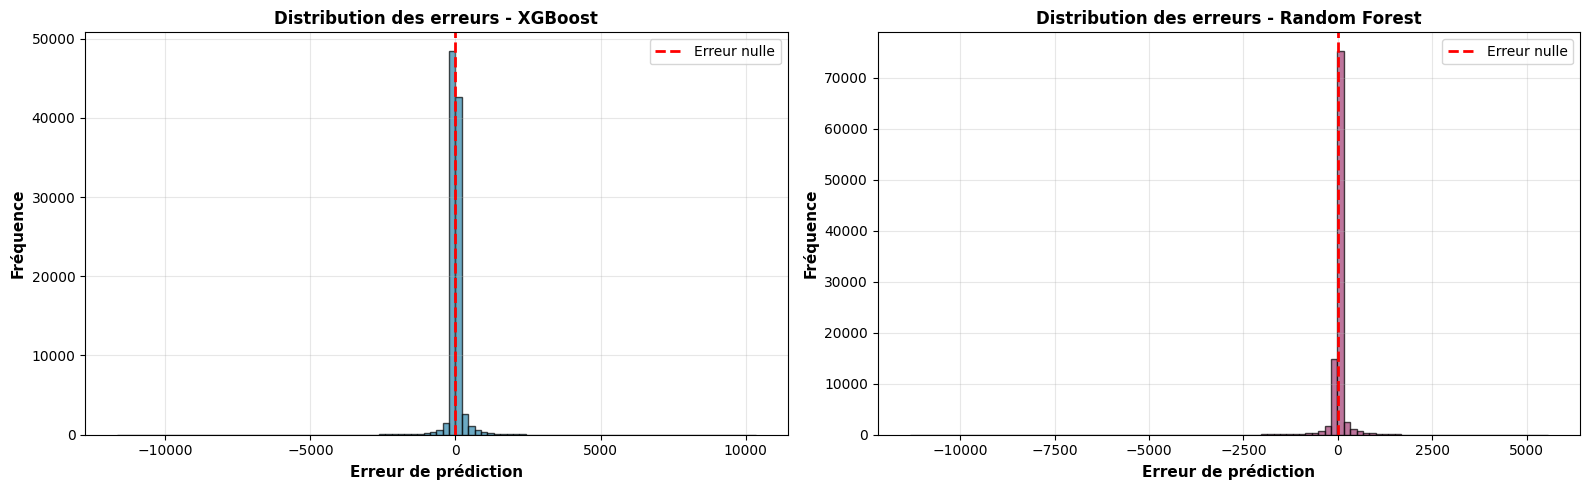

In [22]:
# Calcul des erreurs
pred_val_xgb['error'] = pred_val_xgb['y_pred'] - pred_val_xgb['y_true']
pred_val_rf['error'] = pred_val_rf['y_pred'] - pred_val_rf['y_true']

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# XGBoost
axes[0].hist(pred_val_xgb['error'], bins=100, color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
axes[0].set_xlabel('Erreur de prédiction', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution des erreurs - XGBoost', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].hist(pred_val_rf['error'], bins=100, color='#A23B72', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
axes[1].set_xlabel('Erreur de prédiction', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution des erreurs - Random Forest', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Prédictions vs Valeurs réelles

Nuage de points comparant les prédictions aux valeurs observées.

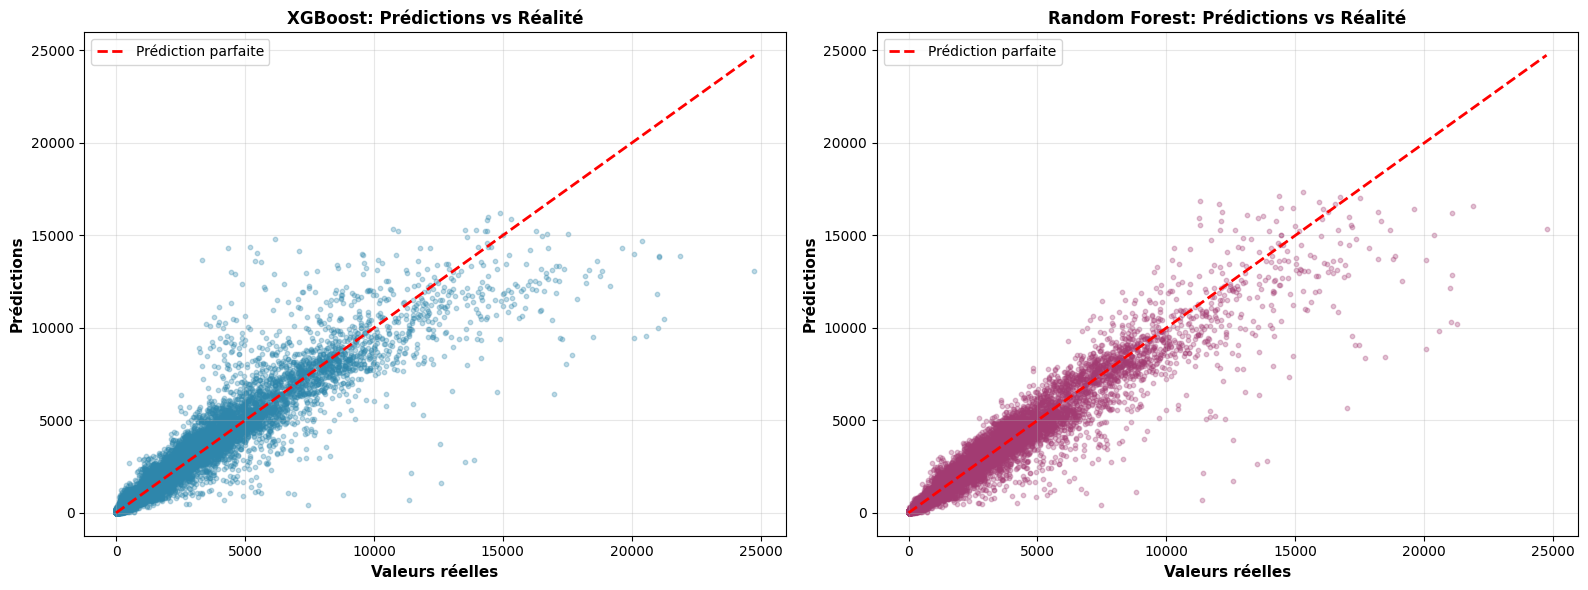

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost
axes[0].scatter(pred_val_xgb['y_true'], pred_val_xgb['y_pred'], 
                alpha=0.3, s=10, color='#2E86AB')
axes[0].plot([0, pred_val_xgb['y_true'].max()], 
             [0, pred_val_xgb['y_true'].max()], 
             'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Prédictions', fontsize=11, fontweight='bold')
axes[0].set_title('XGBoost: Prédictions vs Réalité', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(pred_val_rf['y_true'], pred_val_rf['y_pred'], 
                alpha=0.3, s=10, color='#A23B72')
axes[1].plot([0, pred_val_rf['y_true'].max()], 
             [0, pred_val_rf['y_true'].max()], 
             'r--', linewidth=2, label='Prédiction parfaite')
axes[1].set_xlabel('Valeurs réelles', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Prédictions', fontsize=11, fontweight='bold')
axes[1].set_title('Random Forest: Prédictions vs Réalité', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 Erreurs moyennes par famille de produits

Identification des catégories de produits les plus difficiles à prédire.

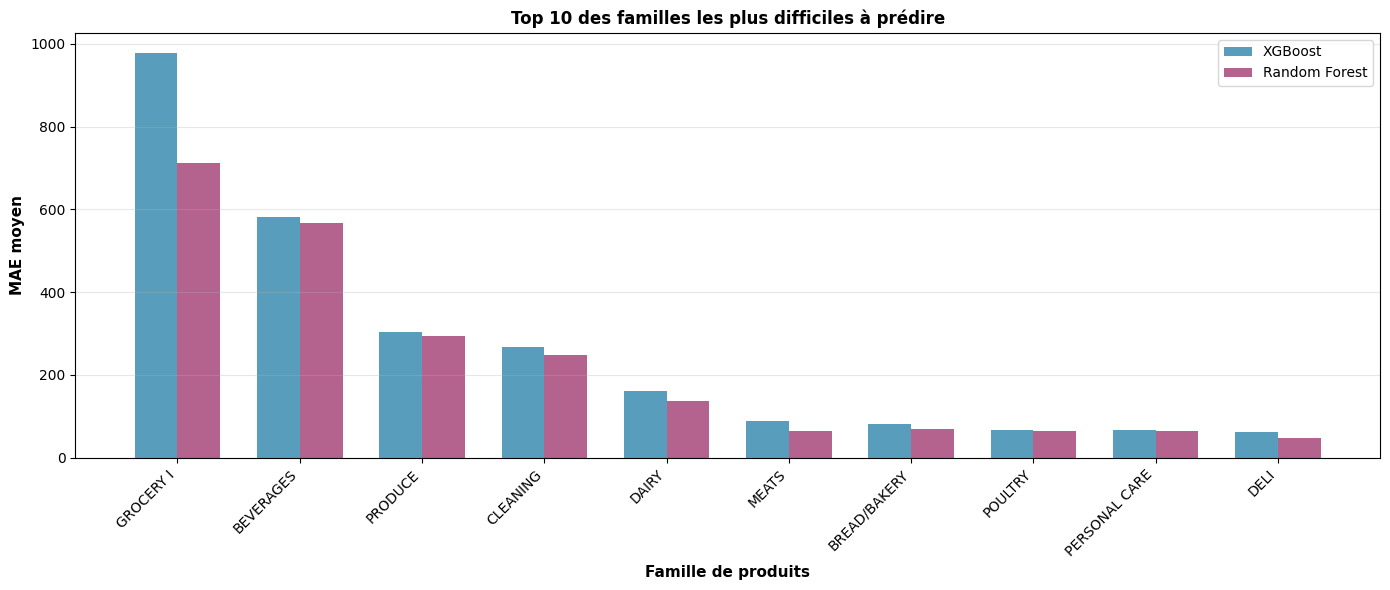

In [24]:
# Calcul des erreurs absolues moyennes par famille
mae_by_family_xgb = pred_val_xgb.groupby('family').apply(
    lambda x: np.abs(x['y_pred'] - x['y_true']).mean()
).sort_values(ascending=False)

mae_by_family_rf = pred_val_rf.groupby('family').apply(
    lambda x: np.abs(x['y_pred'] - x['y_true']).mean()
).sort_values(ascending=False)

# Top 10 des familles les plus difficiles
top_families = mae_by_family_xgb.head(10).index

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(top_families))
width = 0.35

ax.bar(x - width/2, mae_by_family_xgb[top_families], width, 
       label='XGBoost', color='#2E86AB', alpha=0.8)
ax.bar(x + width/2, mae_by_family_rf[top_families], width, 
       label='Random Forest', color='#A23B72', alpha=0.8)

ax.set_xlabel('Famille de produits', fontsize=11, fontweight='bold')
ax.set_ylabel('MAE moyen', fontsize=11, fontweight='bold')
ax.set_title('Top 10 des familles les plus difficiles à prédire', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_families, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 7.4 Évolution temporelle des prédictions

Suivi des prédictions agrégées sur la période de validation.

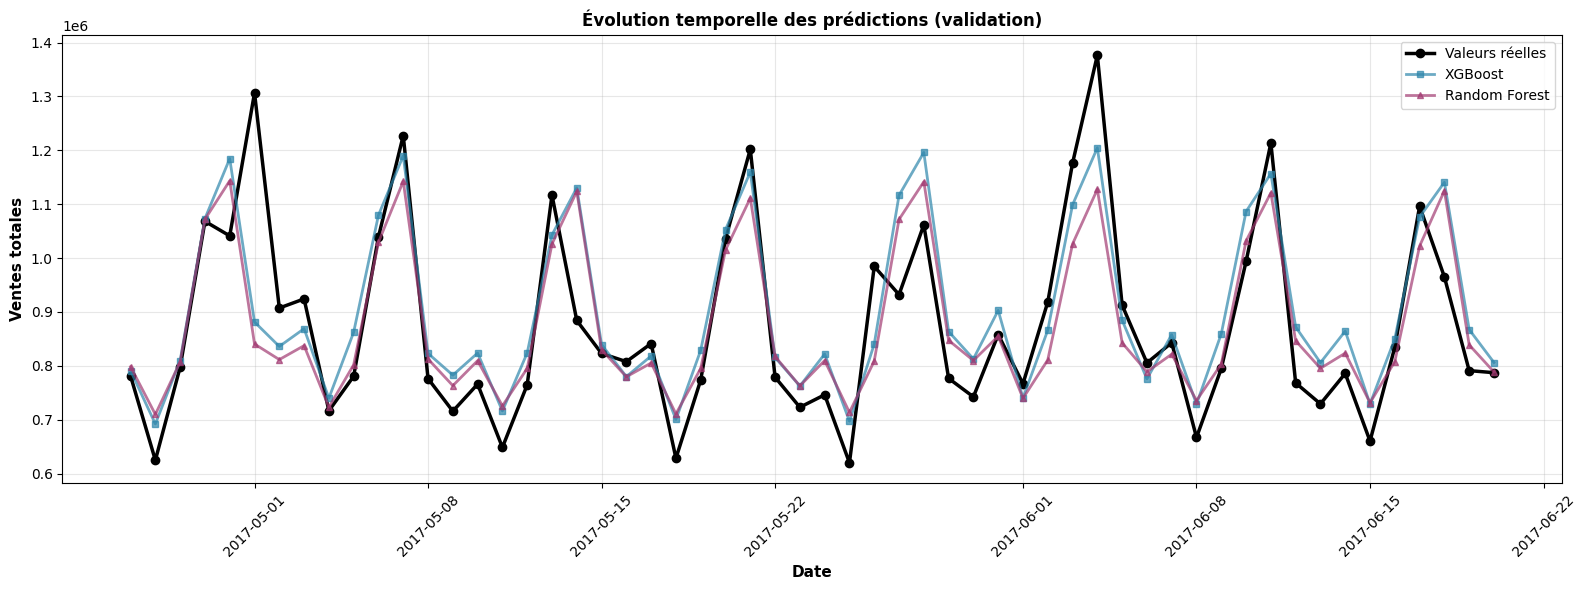

In [25]:
# Agrégation par date
daily_xgb = pred_val_xgb.groupby('date').agg({
    'y_true': 'sum',
    'y_pred': 'sum'
}).reset_index()

daily_rf = pred_val_rf.groupby('date').agg({
    'y_true': 'sum',
    'y_pred': 'sum'
}).reset_index()

# Visualisation
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(daily_xgb['date'], daily_xgb['y_true'], 
        label='Valeurs réelles', color='black', linewidth=2.5, marker='o', markersize=6)
ax.plot(daily_xgb['date'], daily_xgb['y_pred'], 
        label='XGBoost', color='#2E86AB', linewidth=2, marker='s', markersize=5, alpha=0.7)
ax.plot(daily_rf['date'], daily_rf['y_pred'], 
        label='Random Forest', color='#A23B72', linewidth=2, marker='^', markersize=5, alpha=0.7)

ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_ylabel('Ventes totales', fontsize=11, fontweight='bold')
ax.set_title('Évolution temporelle des prédictions (validation)', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 7.5 Erreurs par magasin

Performance des modèles selon les différents points de vente.

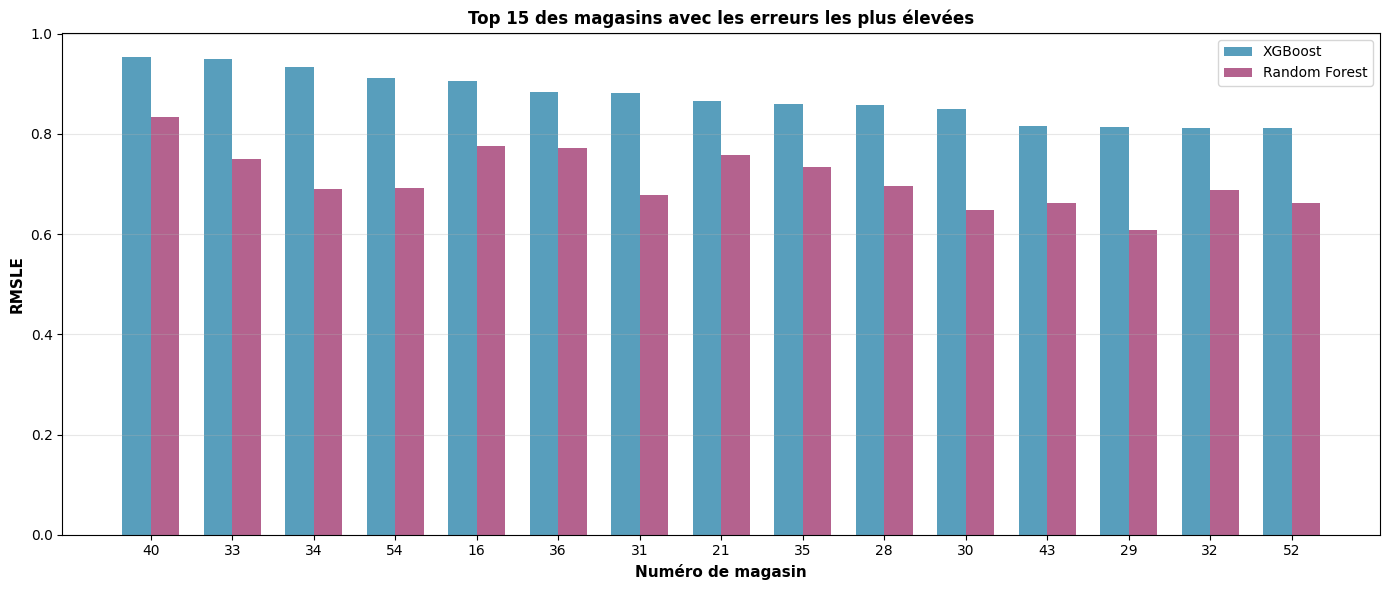

In [26]:
# Calcul du RMSLE par magasin
from sklearn.metrics import mean_squared_log_error

rmsle_by_store_xgb = pred_val_xgb.groupby('store_nbr').apply(
    lambda x: np.sqrt(mean_squared_log_error(x['y_true'], x['y_pred']))
).sort_values(ascending=False)

rmsle_by_store_rf = pred_val_rf.groupby('store_nbr').apply(
    lambda x: np.sqrt(mean_squared_log_error(x['y_true'], x['y_pred']))
).sort_values(ascending=False)

# Top 15 magasins avec plus d'erreurs
top_stores = rmsle_by_store_xgb.head(15).index

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(top_stores))
width = 0.35

ax.bar(x - width/2, rmsle_by_store_xgb[top_stores], width, 
       label='XGBoost', color='#2E86AB', alpha=0.8)
ax.bar(x + width/2, rmsle_by_store_rf[top_stores], width, 
       label='Random Forest', color='#A23B72', alpha=0.8)

ax.set_xlabel('Numéro de magasin', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSLE', fontsize=11, fontweight='bold')
ax.set_title('Top 15 des magasins avec les erreurs les plus élevées', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_stores)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 7.6 Boxplot des erreurs relatives

Distribution des erreurs en pourcentage des valeurs réelles.

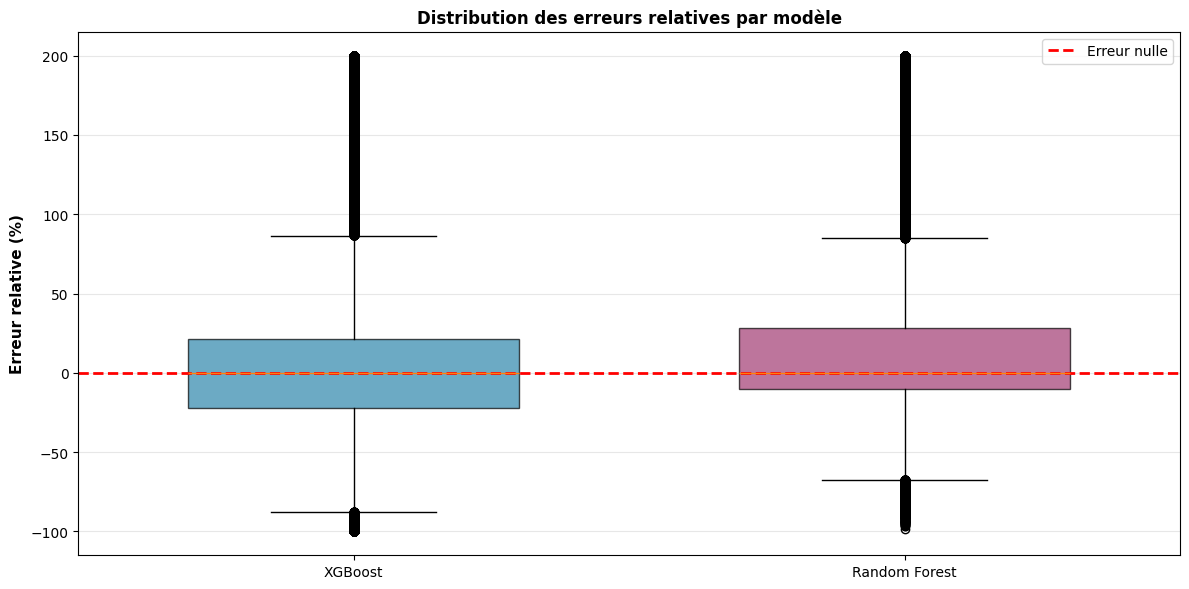

In [27]:
# Calcul des erreurs relatives (en %)
pred_val_xgb['error_pct'] = np.where(
    pred_val_xgb['y_true'] > 0,
    100 * (pred_val_xgb['y_pred'] - pred_val_xgb['y_true']) / pred_val_xgb['y_true'],
    0
)

pred_val_rf['error_pct'] = np.where(
    pred_val_rf['y_true'] > 0,
    100 * (pred_val_rf['y_pred'] - pred_val_rf['y_true']) / pred_val_rf['y_true'],
    0
)

# Limitation des erreurs extrêmes pour une meilleure visualisation
errors_xgb = pred_val_xgb['error_pct'].clip(-200, 200)
errors_rf = pred_val_rf['error_pct'].clip(-200, 200)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot([errors_xgb, errors_rf], 
                 labels=['XGBoost', 'Random Forest'],
                 patch_artist=True,
                 widths=0.6)

# Couleurs
colors = ['#2E86AB', '#A23B72']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
ax.set_ylabel('Erreur relative (%)', fontsize=11, fontweight='bold')
ax.set_title('Distribution des erreurs relatives par modèle', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 7.7 Exemple détaillé sur un magasin/famille spécifique

Zoom sur le couple magasin-famille avec le plus gros volume de ventes.

Analyse détaillée pour:
  Magasin: 45
  Famille: GROCERY I
  Ventes totales: 672,222


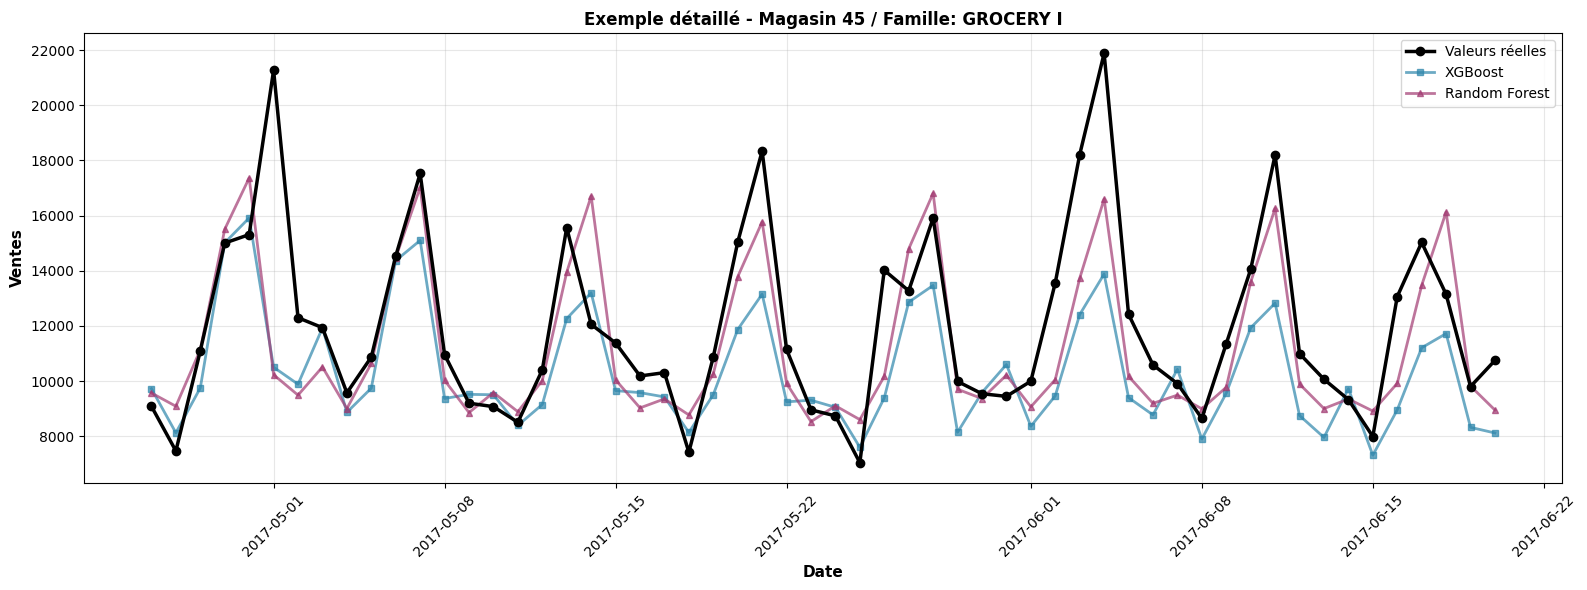

In [28]:
# Identification du couple store/family avec le plus de ventes
store_family_sales = pred_val_xgb.groupby(['store_nbr', 'family'])['y_true'].sum().sort_values(ascending=False)
top_store, top_family = store_family_sales.index[0]

print(f"Analyse détaillée pour:")
print(f"  Magasin: {top_store}")
print(f"  Famille: {top_family}")
print(f"  Ventes totales: {store_family_sales.iloc[0]:,.0f}")

# Extraction des données
pred_xgb_detail = pred_val_xgb[
    (pred_val_xgb['store_nbr'] == top_store) & 
    (pred_val_xgb['family'] == top_family)
].sort_values('date')

pred_rf_detail = pred_val_rf[
    (pred_val_rf['store_nbr'] == top_store) & 
    (pred_val_rf['family'] == top_family)
].sort_values('date')

# Visualisation
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(pred_xgb_detail['date'], pred_xgb_detail['y_true'], 
        label='Valeurs réelles', color='black', linewidth=2.5, 
        marker='o', markersize=6, zorder=3)
ax.plot(pred_xgb_detail['date'], pred_xgb_detail['y_pred'], 
        label='XGBoost', color='#2E86AB', linewidth=2, 
        marker='s', markersize=5, alpha=0.7)
ax.plot(pred_rf_detail['date'], pred_rf_detail['y_pred'], 
        label='Random Forest', color='#A23B72', linewidth=2, 
        marker='^', markersize=5, alpha=0.7)

ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_ylabel('Ventes', fontsize=11, fontweight='bold')
ax.set_title(f'Exemple détaillé - Magasin {top_store} / Famille: {top_family}', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Conclusion

Ce notebook a permis de comparer XGBoost et Random Forest pour la prédiction de séries temporelles de ventes.

**Points clés**:
- Approche récursive permettant d'utiliser les prédictions précédentes comme features
- Encodages optimisés calculés une seule fois
- Split temporel respectant la structure des séries temporelles
- Exclusion des variables oil_price pour éviter le data leakage

**Prochaines étapes possibles**:
- Optimisation fine des hyperparamètres via grid search
- Ajout de features temporelles plus sophistiquées
- Ensemble de modèles (stacking)
- Analyse SHAP pour l'interprétabilité